In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Goto https://keras.io/api/applications/ for getting any transfer learning model based on ImageNet
"""ImageNet is a large-scale image database that was created to serve as a benchmark for visual object recognition research.
It contains over 14 million labeled images spanning 22,000 categories.The ImageNet project gained significant attention in the
computer vision community when it launched the Large Scale Visual Recognition Challenge (ILSVRC) in 2010, which was a
competition designed to evaluate the accuracy of algorithms for object detection and image classification tasks. One of the
key outcomes of the ILSVRC competition was the development of deep convolutional neural networks (CNNs), such as AlexNet, VGG,
and ResNet, which dramatically improved the state-of-the-art performance on object recognition tasks."""

'ImageNet is a large-scale image database that was created to serve as a benchmark for visual object recognition research.\nIt contains over 14 million labeled images spanning 22,000 categories.The ImageNet project gained significant attention in the\ncomputer vision community when it launched the Large Scale Visual Recognition Challenge (ILSVRC) in 2010, which was a\ncompetition designed to evaluate the accuracy of algorithms for object detection and image classification tasks. One of the\nkey outcomes of the ILSVRC competition was the development of deep convolutional neural networks (CNNs), such as AlexNet, VGG,\nand ResNet, which dramatically improved the state-of-the-art performance on object recognition tasks.'

In [ ]:
from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
from keras.models import Sequential
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
#from keras.applications.resnet import ResNet50

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
from glob import glob  # it is a file finder
import matplotlib.pyplot as plt

# re-size all the images to this
# IMAGE_SIZE = [224, 224]

# train_path = '/content/extracted_images/dataset/train'
# valid_path = '/content/extracted_images/dataset/validation'

# add preprocessing layer to the front of VGG(include=False means donot add the last layer)
vgg = VGG16(input_shape=[224,224,3], weights='imagenet', include_top=False)  #include_top=False- this should not contain output layer
                                                                             # include_top=True means ready to predict the output


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# execute this only once... if you run again, skip this part
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/Arificial Intelegence Associate/CVE/5_train.zip", 'r') as zip_ref:        # get the path for train.zip using copypath. paste the link within the quotation
     # creates new folder 'cats_dogs_images' and saves all images present in train.zip
    zip_ref.extractall("/content/extracted_images")  # create a new folder, rename it and get the path of it using copypath.. paste the link here



In [ ]:
import os, shutil, pathlib

original_dir = pathlib.Path("/content/extracted_images/train") # get the path of train folder in cats_dogs_images using copypath and paste the link here
new_base_dir = pathlib.Path(r"/content/extracted_images/dataset") # create a new folder, rename it and get the path using copypath and paste the link here.

def make_subset(subset_name, start_index, end_index):  # subset is name of the folder
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category  # this subset is create train,test,validation. category is it create category cat and category dog it create two folder
        os.makedirs(dir) # makedirs is it create same folder structure
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]# insert variables directly inside the string using { }
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, #
                            dst=dir / fname) #This loop copies each image file from the original folder into a new folder.

#shutil is a Python module used for high-level file operations — especially copying, moving, and deleting files and folders.

# calling the function thrice to create 3 subsets.
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

In [ ]:
# dog = 0     # this code jst counting imgs present in train
# cat = 0
# for i in os.listdir("/content/extracted_images/train"):
#   if 'dog' in i:
#     dog += 1
#   elif 'cat' in i:
#     cat += 1
# print("cat count is {}".format(cat))
# print("dog count is {}".format(dog))




cat count is 12500
dog count is 12500


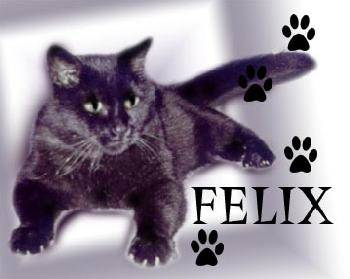

(279, 350, 3)


In [ ]:
from google.colab.patches import cv2_imshow
import cv2
mycat = cv2.imread("/content/extracted_images/dataset/test/cat/cat.1501.jpg")
cv2_imshow(mycat)
print(mycat.shape)

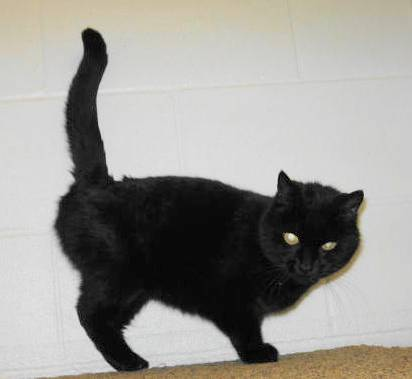

(379, 412, 3)


In [ ]:
mycat = cv2.imread("/content/extracted_images/dataset/test/cat/cat.1605.jpg")
cv2_imshow(mycat)
print(mycat.shape)

In [ ]:
# print(len(train))
# print(len(test))

In [ ]:
# x_train = []
# y_train = []
# x_val = []
# y_val = []

# for feature, label in train:
#   x_train.append(feature)
#   y_train.append(label)

# for feature, label in test:
#   x_val.append(feature)
#   y_val.append(label)

# # Normalize the data
# x_train = np.array(x_train).astype('float32') / 255
# x_val = np.array(x_val).astype('float32') / 255

In [ ]:
# folders = glob('/content/drive/MyDrive/CNN/cats_dogs_images/image_seggrated/train')

In [ ]:
# don't train existing weights
for layer in vgg.layers:
    layer.trainable = False #Freeze the weights “Do NOT change the already learned weights of VGG.”

In [ ]:
#  what is functional api
#  The Keras Functional API is a way to create models that are more flexible than the Sequential API.
#  It allows you to define models as directed acyclic graphs of layers. This means you can create models with shared layers,
#  multiple inputs, multiple outputs, and even complex internal connections.

In [ ]:
# folders = glob('/content/drive/MyDrive/CNN/cats_dogs_images/image_seggrated/train')


# our layers - you can add more if you want
x = Flatten()(vgg.output)
x = Dense(1000, activation='relu')(x) # hiddle layer
prediction = Dense(1, activation='sigmoid')(x)

# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

# view the structure of the model
model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │    25,089,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,804,689 (151.84 MB)

 Trainable params: 25,090,001 (95.71 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# tell the model what cost and optimization method to use
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [ ]:

# useful for getting number of classes
# folders = glob('/content/drive/MyDrive/CNN/cats_dogs_images/image_seggrated/train/*')





from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1/255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory('/content/extracted_images/dataset/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

test_set = test_datagen.flow_from_directory('/content/extracted_images/dataset/validation',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'binary')



Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
len(training_set)

63

In [ ]:
type(training_set)

keras.src.legacy.preprocessing.image.DirectoryIterator

In [ ]:
# fit the model
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
18/63 ━━━━━━━━━━━━━━━━━━━━ 14:04 19s/step - accuracy: 0.5508 - loss: 5.1504

In [ ]:
'''r=model.fit_generator(training_set,
                         samples_per_epoch = 8000,
                         nb_epoch = 5,
                         validation_data = test_set,
                         nb_val_samples = 2000)'''


# loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# accuracies
plt.plot(r.history['acc'], label='train acc')
plt.plot(r.history['val_acc'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

import tensorflow as tf

from keras.models import load_model

model.save('facefeatures_new_model.h5')